In [169]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/utenteadmin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [170]:
text1 = " ‘ andrea ’ sangio ‘ jana ... forver ’ “  together at ferrari”  "
print(replace_quote_symbols(text1))

  <LEFT_SINGLE_QUOTE>  andrea  <RIGHT_SINGLE_QUOTE>  sangio  <LEFT_SINGLE_QUOTE>  jana  <ELLIPSIS>  forver  <RIGHT_SINGLE_QUOTE>   <LEFT_DOUBLE_QUOTE>   together at ferrari <RIGHT_DOUBLE_QUOTE>   


In [171]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return 'n'

def lem_text(text, lemmatizer = WordNetLemmatizer(), tokenizer = WhitespaceTokenizer(), spell_checker=True, spell=Speller(lang='en')):
    tokens = tokenizer.tokenize(text)
    if spell_checker:
      tokens = [spell(w) for w in tokens]
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
    return " ".join(words)

### Sources:

*   [GloVe Embedding article](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)
*    [Emojis - source1](https://towardsdatascience.com/emojis-aid-social-media-sentiment-analysis-stop-cleaning-them-out-bb32a1e5fc8e)
*   [Emojis - source2](https://medium.com/@HeCanThink/emoji-lets-deal-with-in-python-dcc88b1f8ab1)
*   [Emojis - source3](https://kt.ijs.si/data/Emoji_sentiment_ranking/)
*   [Spell checker - source 1](https://www.johnsnowlabs.com/easily-correcting-typos-and-spelling-errors-on-texts-with-spark-nlp-and-python/)
*   [Spell checker - source 2](https://stackoverflow.com/questions/69851442/q-python-spell-checker-using-nltk)
*   [Lemmatization with a pretrained model - Spark NLP](https://sparknlp.org/2021/11/22/lemma_antbnc_en.html)

In [285]:
import pandas as pd
import gensim
import emoji
import nltk
import torch
import sys
import shutil
import urllib
import tarfile
from pathlib import Path
import numpy as np
from typing import Iterable
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import gensim.downloader as gloader
from autocorrect import Speller
import os

import re

## hashtags segmenter: https://github.com/grantjenks/python-wordsegment
import wordsegment as ws 
ws.load()

## mention and lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

LEMMATIZED_TRAIN_DATA_FILE = "training_data_lemm.csv"

In [173]:
# choose right device
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print('Torch Device: %s' % device)

Torch Device: mps


# Data Visualization
Download data, Load Json in Pandas dataframes, Generate Hard Labels, Filter English, Filter columns, Encode Hard Label in 0-1

# Data Cleaning

In [286]:
## REGEXs
REPLACE_BY_SPACE_RE = re.compile('[/(){}\[\]\|@,;]')
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z #+_<>]')
HASHTAG_REGEX = re.compile('#\w+')
MENTION_REGEX = re.compile("@\w+")
URL_REGEX = re.compile('https?://(?:www\.)?[\w-]+\.[\w/._-]+')
## SPECIAL TOKENs
TOKEN_LESSER_THAN = "<LESSER_THAN>"
TOKEN_GREATER_THAN = "<GREATER_THAN>"
TOKEN_LEFT_SINGLE_QUOTE = "<LEFT_SINGLE_QUOTE>"
TOKEN_RIGHT_SINGLE_QUOTE = "<RIGHT_SINGLE_QUOTE>"
TOKEN_LEFT_DOUBLE_QUOTE = "<LEFT_DOUBLE_QUOTE>"
TOKEN_RIGHT_DOUBLE_QUOTE = "<RIGHT_DOUBLE_QUOTE>"
TOKEN_ELLIPSIS = "<ELLIPSIS>"
TOKEN_LESSER_THAN = "<LESSER_THAN>"
TOKEN_LESSER_THAN = "<LESSER_THAN>"
TOKEN_URL = "<URL>"
TOKEN_HASHTAG_START = "<HASHTAG_START>"
TOKEN_HASHTAG_END = "<HASHTAG_END>"

try:
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    STOPWORDS = set(stopwords.words('english'))

In [288]:
def lower(text):
    return text.lower()

def strip_text(text):
    return text.strip()

def contains_emoji(text):
    return any(emoji.is_emoji(char) for char in text)

def contains_mention(text):
    return re.findall(MENTION_REGEX, text)

def replace_urls_with_token(text):
    return re.sub(URL_REGEX, TOKEN_URL, text)

def remove_angle_brackets(text):
    text.replace("&amp", " and ")
    text.replace("<", TOKEN_LESSER_THAN)
    text.replace(">", TOKEN_GREATER_THAN)
    return text

def emoji2description(text):
    return emoji.replace_emoji(text, replace=lambda chars, data_dict: ' '.join(data_dict['en'].split('_')).strip(':')+' ')

def encode_data_with_function(data, encoding, column = 'tweet'):
    data[column] = data[column].apply(encoding)
    return data

def replace_quote_symbols(text):
    text = text.replace("‘", TOKEN_LEFT_SINGLE_QUOTE)
    text = text.replace("’", TOKEN_RIGHT_SINGLE_QUOTE)
    text = text.replace("“", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("”", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("...", TOKEN_ELLIPSIS)
    return text

def replace_mention(text):
    mention = re.findall(MENTION_REGEX, text)
    if mention:
        new_sen = text
        for m in mention:
            doc = nlp(m)
            sub = [c.label_ for c in doc.ents]
            if sub:
                new_sen = new_sen.replace(m, f"<{sub[0]}>")
            else:
                new_sen = new_sen.replace(m, f"<{[c.pos_ for c in doc][0]}>")
        return new_sen
    else:
        return text    
    
def replace_hashtag(text):
    """
    Replaces hashtags, by segmenting hashtags and adding special tokens in front and at the end of it.
    """
    def segment(x) :
        return TOKEN_HASHTAG_START+' '.join(ws.segment(x))+TOKEN_HASHTAG_END
    return re.sub(HASHTAG_REGEX, lambda x: segment(x.group(0)), text)


def replace_special_characters(text: str) -> str:
    """
    Replaces special characters, such as paranthesis, with spacing character
    """
    return REPLACE_BY_SPACE_RE.sub(' ', text)

def replace_br(text: str) -> str:
    """
    Replaces br characters
    """
    return text.replace('br', '')

def filter_out_uncommon_symbols(text: str) -> str:
    """
    Removes any special character that is not in the good symbols list (check regular expression)
    """
    return GOOD_SYMBOLS_RE.sub('', text)

def remove_stopwords(text: str) -> str:
    return ' '.join([x for x in text.split() if x and x not in STOPWORDS])

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing (including carriage return) from text.
    """
    return text.strip()

In [289]:
def majority_vote(lst):
    count = Counter(lst)
    return 1 if count.most_common(1)[0][0] == "YES" else 0

def yes_probability(lst):
    # Count the number of YES and NO votes
    yes_count = lst.count("YES")
    no_count = lst.count("NO")
    
    # Calculate the probability of YES
    total = yes_count + no_count
    if total == 0:
        return None  # To handle cases where there are no "YES" or "NO" votes in the list
    else:
        return yes_count / total

def generate_labels_task1(data):
    data = data.drop(['annotators','number_annotators','gender_annotators','age_annotators','labels_task2','labels_task3'],axis=1)
    data['hard_label_task1'] = data['labels_task1'].apply(majority_vote)
    data['soft_label_task1'] = data['labels_task1'].apply(yes_probability)
    return data

def load_and_preprocess_dataset(file_path):
    data = pd.read_json(file_path).T
    data = generate_labels_task1(data)
    data['original'] = data['tweet'] #to remove
    columns_to_keep = ['id_EXIST','lang','tweet', 'hard_label_task1','soft_label_task1', 'original']
    data = data[columns_to_keep]
    data = filter_english_only(data)
    data = encode_data_with_function(data,remove_angle_brackets)
    data = encode_data_with_function(data,emoji2description)
    data = encode_data_with_function(data,replace_mention)
    data = encode_data_with_function(data,replace_hashtag)
    data = encode_data_with_function(data,replace_urls_with_token) 
    data = encode_data_with_function(data,replace_quote_symbols)
    data = encode_data_with_function(data,replace_special_characters)
    #data = encode_data_with_function(data,replace_br)
    data = encode_data_with_function(data,remove_stopwords)
    data = encode_data_with_function(data,strip_text)
    data = encode_data_with_function(data,lower)
    data = encode_data_with_function(data,filter_out_uncommon_symbols)
    data = encode_data_with_function(data,strip_text)
    return data

def filter_english_only(df):
    new_df = df[df['lang'].astype('str').str.contains('en')]
    return new_df


In [290]:
training_data = load_and_preprocess_dataset("data/training.json")
print('Finished training')
validation_data = load_and_preprocess_dataset("data/validation.json")
print('Finished validation')
test_data = load_and_preprocess_dataset("data/test.json")
print('Finished test')

Finished training
Finished validation
Finished test


In [178]:
print(training_data.shape)
print(validation_data.shape)
print(test_data.shape)

print(training_data.columns)


(3260, 6)
(177, 6)
(312, 6)
Index(['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1',
       'original'],
      dtype='object')


In [291]:
display(training_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs how laying blame bastard murdered her nove...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 i dont appreciate two rides t...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed s...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote>making harder target<right_...,1,0.500000,‘Making yourself a harder target’ basically bo...


In [180]:
display(test_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
400178,400178,en,1st day pool beautiful sunday ny too bad dared...,0,0.000000,1st day at the pool on a beautiful Sunday in N...
400179,400179,en,<left_double_quote> i like outfit except dress...,1,0.833333,“I like your outfit too except when i dress up...
400180,400180,en,<product> pleading face sparkling heart though...,0,0.000000,"@KNasFanFic 🥺💖 same, though!!! the angst just ..."
400181,400181,en,<noun> <x> fuck cunt tried vote multiple times,1,0.833333,@themaxburns @GOP Fuck that cunt. Tried to vot...
400182,400182,en,<org> u gotta say shit like <left_double_quote...,1,1.000000,@ultshunnie u gotta say some shit like “i’ll f...


In [293]:
target = "hard_label_task1"

In [294]:
training_data[target].value_counts()

hard_label_task1
0    1941
1    1319
Name: count, dtype: int64

Train '0:1' score ratio --> 1.47 : 1
Test  '0:1' score ratio --> 1.21 : 1


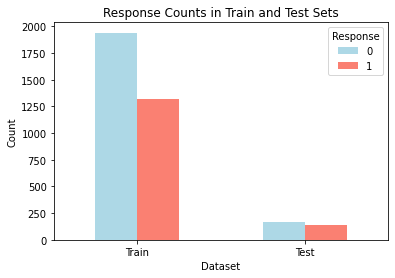

In [295]:
train_counts = training_data[target].value_counts()
test_counts = test_data[target].value_counts()

# Combine counts into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).T  # Transpose to have "yes" and "no" as columns

print(f"Train '0:1' score ratio --> {counts_df[0]['Train']/counts_df[1]['Train']:.2f} : 1")
print(f"Test  '0:1' score ratio --> {counts_df[0]['Test']/counts_df[1]['Test']:.2f} : 1")

# Plotting
counts_df.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Response Counts in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

## Lemmatization - Same as Tutorial 1

In [193]:

# def lemmatize_sentences(sentences):
#     lemmatized_sentences = []
#     for sen in sentences:
#         doc = nlp(sen)
#         lemmatized_sentence = " ".join([token.lemma_ for token in doc])
#         lemmatized_sentences.append(lemmatized_sentence)
#     return np.array(lemmatized_sentences)

In [220]:
training_data.to_csv(LEMMATIZED_TRAIN_DATA_FILE)

In [221]:
if not os.path.isfile(LEMMATIZED_TRAIN_DATA_FILE):
    training_data = encode_data_with_function(training_data,lem_text)
    training_data.to_csv(LEMMATIZED_TRAIN_DATA_FILE)
else:
    training_data = pd.read_csv(LEMMATIZED_TRAIN_DATA_FILE)

# Example
# sentences = ["Cats are running.", "JAHA was cooking some potatoes"]
# #clean_lemmas = lemmatize_sentences(sentences)
# #print(clean_lemmas)
# for sentence in sentences:
#     print(lem_text(sentence))

# Text encoding

In [211]:
embeddings_dict = {}


In [212]:

def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider
 
    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

In [213]:
embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=200)

In [198]:
# with open("C:/Users/andre/Desktop/AlmaMater/NLP/Assignment/Assignment 1/NLP_AssignmentOne/glove.twitter.27B.100d.txt", 'r', encoding="utf-8") as f:
#     for line in f:
#         values = line.split()
#         word = values[0]
#         vector = np.asarray(values[1:], "float32")
#         embeddings_dict[word] = vector

In [214]:
N = 40  # Numero di parole da visualizzare
for i, (word, vector) in enumerate(embeddings_dict.items()):
    print(f"{word}: {vector}")
    if i == N - 1:  # Fermati dopo aver stampato N parole
        break

In [215]:
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

In [216]:
check_OOV_terms(word_listing=training_data)

TypeError: check_OOV_terms() missing 1 required positional argument: 'embedding_model'